# Question 1

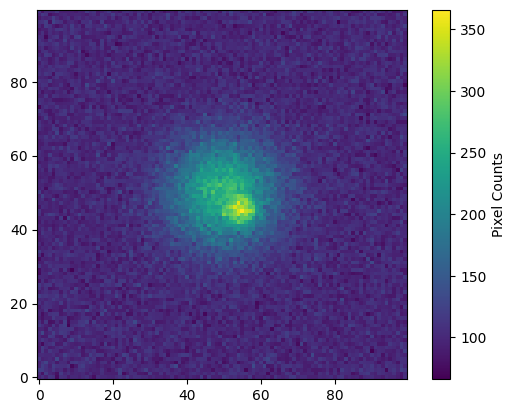

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Create 1D coordinate ranges from 0 to 99
x = np.arange(100)
y = np.arange(100)

# Generate the 2D coordinate matrices
X, Y = np.meshgrid(x, y)

# Building a sky baseline
base = np.full((100,100),100, dtype=float)

# Generating a Gaussian
def gauss_gen(x, y, a, b, sig, tot):
    amp = tot/(2*np.pi*sig**2)
    exp = -((x-a)**2 + (y-b)**2)/(2*sig**2)
    gauss = amp*np.exp(exp)
    return gauss

# Parameters of the galaxy
a_g,b_g = 50, 50
sig_g = 10
flux_g = 100000

gal = gauss_gen(X, Y, a_g, b_g, sig_g, flux_g)

# Parameter of the supernova
a_s, b_s = 55, 45
sig_s = 2.5
flux_s = 5000

sup = gauss_gen(X, Y, a_s,b_s, sig_s, flux_s)

#Creating the image and adding a random draw using pixel distribution

truth_image = base + gal + sup

ccd = np.random.poisson(lam=truth_image)

# Displaying the generated frame
plt.imshow(ccd, cmap='viridis', origin='lower')
plt.colorbar(label='Pixel Counts')
plt.show()

In [27]:
# Defining the centre and calculating distances from it

R = np.sqrt((X-55)**2 + (Y-45)**2)

# Defining the aperture

app = R <= 3 * sig_s

# Defining the annulus

ann_in = 4 * sig_s
ann_out = 6 * sig_s

ann = (R>=ann_in) & (R<=ann_out)

# Calculating the background noise
ann_flux_values = ccd[ann]
bkg = np.median(ann_flux_values)

# Calculating signal + noise from aperture
ap_flux_values = ccd[app]
flux = np.sum(ap_flux_values)

#Subtracting background noise from star to obtain m_inst
F_measured = flux - (bkg*len(ap_flux_values))

# Calculate Instrumental Magnitude
m_inst = -2.5 * np.log10(F_measured)

print('The total flux of the calibrated aperture is', F_measured)
print('The instrumental magnitude is',m_inst)

The total flux of the calibrated aperture is 14262.0
The instrumental magnitude is -10.385451080279559


In [28]:
# Calculate Apparent Magnitude and Luminosity distance in Mpc (1000000 pc)
# m = m_inst + ZP
# m - M = 5log(d) - 5
M = -19.3 # for type 1a supernova

m = m_inst + 30.0

d = 10**((m-M+5)/5)

d_l = d/1000000

# Use Hubble's constant to calculate recession velocity
H_0 = 70 #km s**(-1) Mpc**(-1)
v = H_0 * d_l

# Using linear doppler approximation, z = v/c
c = 3e5
z = v/c

print('Apparent magnitude =', m)
print('Luminosity distance =', d_l,'Mpc')
print('Recession velocity =',v,'km s^(-1)')
print('Redshift (approximated) =',z)

Apparent magnitude = 19.61454891972044
Luminosity distance = 606.6103052524655 Mpc
Recession velocity = 42462.72136767259 km s^(-1)
Redshift (approximated) = 0.14154240455890862


# Question 2

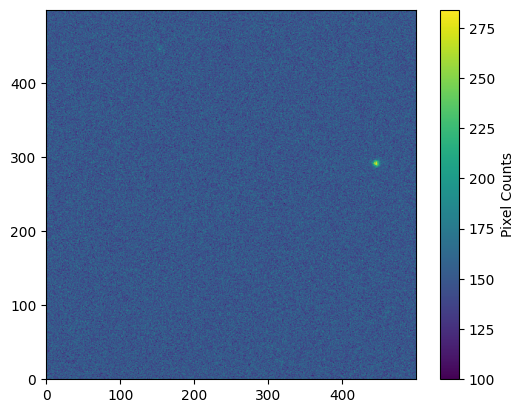

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Create 1D coordinate ranges from 0 to 99
p = np.arange(500)
q = np.arange(500)

# Generate the 2D coordinate matrices
P, Q = np.meshgrid(p, q)

# Building a sky baseline
base = np.full((500,500),150, dtype=float)

# Calculating total flux from an instrumental magnitude
def flux(z):
    v = z * 3e5
    d = (v/70)*1000000
    m = -19.3 + 5*np.log10(d) - 5
    m_inst = m - 25
    flux = 10 ** (m_inst/(-2.5))
    return flux

# Generating the gaussians of the 5 supernovae

z_list = [0.02, 0.05, 0.08, 0.11, 0.15]
centres = np.random.randint(9, 491, size=(5, 2)) #The range has been truncated so that no supernova is too close to the edge
f_list = []
g_list = []

for i in range(len(z_list)):
    z = z_list[i]
    f = flux(z)
    f_list.append(f)
    a,b = centres[i]
    g = gauss_gen(P, Q, a, b, 3, f)
    g_list.append(g)

# Sum all the isolated supernovae together into one layer
supernovae = sum(g_list)

# Combine with the sky background baseline
image = base + supernovae

# Apply the real physics of measurement
ccd_2 = np.random.poisson(lam=image)

# Displaying the generated frame
plt.imshow(ccd_2, cmap='viridis', origin='lower')
plt.colorbar(label='Pixel Counts')
plt.show()

In [30]:
def app_phot(ccd, X, Y, x0, y0, sig_s):
    """Calculates background-subtracted flux, flux uncertainty,

    and instrumental magnitude using aperture photometry.
    """
    R = np.sqrt((X - x0) ** 2 + (Y - y0) ** 2)

    app = R <= 3 * sig_s
    ann = (R >= 4 * sig_s) & (R <= 6 * sig_s)

    bkg = np.median(ccd[ann])
    total_aperture_flux = np.sum(ccd[app])

    num_aperture_pixels = np.sum(app)
    F_measured = total_aperture_flux - (bkg * num_aperture_pixels)

    # Simplified CCD noise equation: sqrt(F_meas + n_pix * B_med)
    inside_sqrt = F_measured + (num_aperture_pixels * bkg)
    sigma_F = np.sqrt(max(inside_sqrt, 0))

    m_inst = -2.5 * np.log10(F_measured) if F_measured > 0 else np.nan

    return F_measured, sigma_F, m_inst

fluxes = []
flux_dev = []
inst_m = []

for i in range(len(centres)):
    x_center, y_center = centres[i]

    # Call the shortened function
    f_meas, f_err, m_meas = app_phot(
        ccd_2, P, Q, x_center, y_center, sig_s=3.0
    )

    fluxes.append(f_meas)
    flux_dev.append(f_err)
    inst_m.append(m_meas)

In [35]:
# Convert lists to arrays for easier manipulation
fluxes = np.array(fluxes)
flux_dev = np.array(flux_dev)
inst_m = np.array(inst_m)
z_data = np.array(z_list)

# 1. Calibrate to Apparent Magnitudes
m_app = inst_m + 25.0

# 2. Propagate Flux Error to Magnitude Error
dev_app_m = (2.5 / np.log(10)) * (flux_dev / fluxes)

# 3. Calculate Distance Modulus and its Uncertainty
mu = m_app - (-19.3)
mu_dev = dev_app_m  # Uncertainty transfers exactly

In [37]:
from scipy.optimize import curve_fit

# The theoretical distance modulus formula as a function of redshift (z) and H0
def hubble_model(z, H0):
    c = 3e5  # Speed of light in km/s
    d_mpc = (c * z) / H0
    return 5 * np.log10(d_mpc) + 25

popt, pcov = curve_fit(
    hubble_model, z_data, mu, p0=[75.0], sigma=mu_dev, absolute_sigma=True
)

# Extract the final answer and its experimental uncertainty
H0_estimated = popt[0]
H0_error = np.sqrt(pcov[0][0])

print(H0_estimated)
print(H0_error)

68.19040354291872
1.0565339279823192
